# 1. Import Libraries

In [1]:
!pip install transformers torch nltk

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip uninstall -y tokenizers transformers torch
!pip install --no-cache-dir transformers tokenizers torch --upgrade

Found existing installation: tokenizers 0.22.2


error: uninstall-no-record-file

× Cannot uninstall tokenizers 0.22.2
╰─> The package's contents are unknown: no RECORD file was found for tokenizers.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps tokenizers==0.22.2


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.8/114.6 MB 2.0 MB/s eta 0:00:58
    --------------------------------------- 1.8/114.6 MB 2.7 MB/s eta 0:00:42
    --------------------------------------- 2.4/114.6 MB 2.7 MB/s eta 0:00:41
   - -------------------------------------- 3.1/114.6 MB 3.1 MB/s eta 0:00:37
   - -------------------------------------- 3.4/114.6 MB 2.6 MB/s eta 0:00:44
   - -------------------------------------- 3.4/114.6 MB 2.6 MB/s eta 0:00:44
   - -------------------------------------- 3.7/114.6 MB 2.3 MB/s eta 0:00:48
   - -------------------------------------- 3.9/114.6 MB 2.0 MB/s eta 0:00:56
   - ---------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchvision 0.18.1 requires torch==2.3.1, but you have torch 2.11.0 which is incompatible.
ultralytics 8.2.51 requires numpy<2.0.0,>=1.23.0, but you have numpy 2.0.2 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 2. Import Pipeline

In [1]:
from transformers import pipeline

pretrained_name = "w11wo/indonesian-roberta-base-sentiment-classifier"

classifier = pipeline(
    "sentiment-analysis",
    model=pretrained_name,
    tokenizer=pretrained_name,
)

d:\Code\kelompok-7-pba\nlp-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4491.05it/s]


# 3. Try Model

In [10]:
text = "Ekonomi Indonesia sedang tumbuh dengan baik"
print(classifier(text))

text = "Ekonomi Indonesia sedang tumbuh dengan jelek"
print(classifier(text))

[{'label': 'positive', 'score': 0.9899829626083374}]
[{'label': 'negative', 'score': 0.9991164803504944}]


# 4. Import Data

In [2]:
import pandas as pd

df = pd.read_csv("../preprocessed/dataset_preprocessed.csv")
df

,no,url,judul,konten,manual sentiment,konten_length,konten_preprocessed
0,1,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,8326,indonesia amerika serikat resmi milik presiden...
1,2,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,2925,indonesia nilai tukar rupiah dolar amerika ser...
2,3,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,13102,indonesia pasar uang indonesia kuat lantik don...
3,4,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative,5158,indonesia indeks harga saham gabung ihsg ambru...
4,5,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive,4767,hargabitcoin btc lewat angka tinggi kisara pic...
...,...,...,...,...,...,...,...
994,997,https://voi.id/teknologi/489452/produsen-mesin...,Produsen Mesin Bitcoin China Pindahkan Produks...,JAKARTA - Tiga produsen mesin penambang bitcoi...,Positive,3756,produsen mesin tambang bitcoin besar dunia chi...
995,998,https://www.liputan6.com/bisnis/read/6058462/d...,Donald Trump Kembali Tekan Ketua The Fed Jerom...,Presiden Amerika Serikat (AS) Donald Trump men...,Netral,3319,presiden amerika serikat donald trump aku sera...
996,999,https://kabar24.bisnis.com/read/20250622/19/18...,"Donald Trump Serang Iran, Ekonomi Global Bakal...","Bisnis.com,JAKARTA — Serangan Amerika Serikat ...",Negative,4713,bisnis com serang amerika serikat fasilitas nu...
997,1000,https://www.cnbcindonesia.com/tech/20250620153...,Trump 'Palak' Raksasa Teknologi Rp 900 Triliun...,"Jakarta, CNBC Indonesia -Perusahaan semikonduk...",Negative,2830,indonesia usaha semikonduktor amerika serikat ...


# EDA

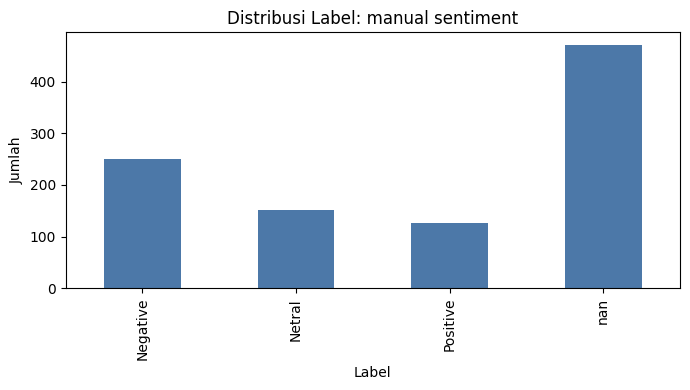

,count
manual sentiment,
Negative,250
Netral,151
Positive,126
NaN,472


In [4]:
import matplotlib.pyplot as plt

# Pick a label column that exists in the dataset
label_candidates = [
    "manual sentiment",
    # "label",
    # "sentiment",
    # "true_label",
    # "pred_label",
    # "label_bert",
]
label_col = next((col for col in label_candidates if col in df.columns), None)
if label_col is None:
    raise ValueError(f"No label column found. Available columns: {list(df.columns)}")

label_counts = df[label_col].value_counts(dropna=False).sort_index()

ax = label_counts.plot(kind="bar", color="#4C78A8", figsize=(7, 4))
ax.set_title(f"Distribusi Label: {label_col}")
ax.set_xlabel("Label")
ax.set_ylabel("Jumlah")
plt.tight_layout()
plt.show()

label_counts.to_frame("count")

# 5. Perform Sentiment Analysis

In [ ]:
df["sentiment_bert"] = df["konten_preprocessed"].apply(lambda x: classifier(x[:256])[0])

df["label_bert"] = df["sentiment_bert"].apply(lambda x: x["label"])
df["score_bert"] = df["sentiment_bert"].apply(lambda x: x["score"])

In [ ]:
df

,no,url,judul,konten,manual sentiment,konten_length,konten_preprocessed,sentiment_bert,label_bert,score_bert
0,1,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,8326,indonesia amerika serikat resmi milik presiden...,"{'label': 'neutral', 'score': 0.998056173324585}",neutral,0.998056
1,2,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,2925,indonesia nilai tukar rupiah dolar amerika ser...,"{'label': 'neutral', 'score': 0.9974008798599243}",neutral,0.997401
2,3,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,13102,indonesia pasar uang indonesia kuat lantik don...,"{'label': 'neutral', 'score': 0.9941151142120361}",neutral,0.994115
3,4,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative,5158,indonesia indeks harga saham gabung ihsg ambru...,"{'label': 'neutral', 'score': 0.9969649910926819}",neutral,0.996965
4,5,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive,4767,hargabitcoin btc lewat angka tinggi kisara pic...,"{'label': 'neutral', 'score': 0.9969125986099243}",neutral,0.996913
...,...,...,...,...,...,...,...,...,...,...
994,997,https://voi.id/teknologi/489452/produsen-mesin...,Produsen Mesin Bitcoin China Pindahkan Produks...,JAKARTA - Tiga produsen mesin penambang bitcoi...,Positive,3756,produsen mesin tambang bitcoin besar dunia chi...,"{'label': 'neutral', 'score': 0.99815434217453}",neutral,0.998154
995,998,https://www.liputan6.com/bisnis/read/6058462/d...,Donald Trump Kembali Tekan Ketua The Fed Jerom...,Presiden Amerika Serikat (AS) Donald Trump men...,Netral,3319,presiden amerika serikat donald trump aku sera...,"{'label': 'neutral', 'score': 0.9966795444488525}",neutral,0.996680
996,999,https://kabar24.bisnis.com/read/20250622/19/18...,"Donald Trump Serang Iran, Ekonomi Global Bakal...","Bisnis.com,JAKARTA — Serangan Amerika Serikat ...",Negative,4713,bisnis com serang amerika serikat fasilitas nu...,"{'label': 'neutral', 'score': 0.9978898167610168}",neutral,0.997890
997,1000,https://www.cnbcindonesia.com/tech/20250620153...,Trump 'Palak' Raksasa Teknologi Rp 900 Triliun...,"Jakarta, CNBC Indonesia -Perusahaan semikonduk...",Negative,2830,indonesia usaha semikonduktor amerika serikat ...,"{'label': 'neutral', 'score': 0.9981206059455872}",neutral,0.998121


## Test Sentiment

In [12]:
# ambil text
texts = df["konten_preprocessed"].tolist()

# prediksi
predictions = classifier(
    texts,
    truncation=True,
    max_length=512,
    batch_size=8
)

# ambil label saja
df["pred_label"] = [pred["label"].lower() for pred in predictions]

In [ ]:
label_map = {
    "positive": "positif",
    "negative": "negatif",
    "neutral": "Neutral"
}

df["pred_label"] = df["pred_label"].map(label_map)
df["true_label"] = df["manual sentiment"].str.lower()

In [16]:
df_clean = df.dropna(subset=["true_label", "pred_label"])
df_clean["true_label"] = df_clean["true_label"].astype(str)
df_clean["pred_label"] = df_clean["pred_label"].astype(str)

In [ ]:
label_map = {
    "positive": "positif",
    "negative": "negatif",
    "neutral": "Neutral"
}

In [19]:
df[df["pred_label"].isna()][["konten_preprocessed"]].head()

,konten_preprocessed


In [20]:
# bersihin
df_clean = df.dropna(subset=["true_label", "pred_label"])

# ambil
y_true = df_clean["true_label"].astype(str)
y_pred = df_clean["pred_label"].astype(str)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall:", recall_score(y_true, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Accuracy: 0.286527514231499
Precision: 0.08272591711081521
Recall: 0.286527514231499
F1 Score: 0.1283847318960129

Classification Report:
              precision    recall  f1-score   support

     negatif       0.00      0.00      0.00         0
    negative       0.00      0.00      0.00       250
      netral       0.29      1.00      0.45       151
    positive       0.00      0.00      0.00       126

    accuracy                           0.29       527
   macro avg       0.07      0.25      0.11       527
weighted avg       0.08      0.29      0.13       527



d:\Code\kelompok-7-pba\nlp-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Code\kelompok-7-pba\nlp-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Code\kelompok-7-pba\nlp-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Code\kelompok-7

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

# fitur & label
X = df_clean["konten_preprocessed"]
y = df_clean["true_label"]

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# prediksi
y_pred = model.predict(X_test_tfidf)

# metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.5471698113207547
Precision: 0.5546482744041012
Recall: 0.5471698113207547
F1 Score: 0.48069205857504926

Classification Report:
              precision    recall  f1-score   support

    negative       0.55      0.92      0.69        50
      netral       0.53      0.29      0.38        31
    positive       0.60      0.12      0.20        25

    accuracy                           0.55       106
   macro avg       0.56      0.44      0.42       106
weighted avg       0.55      0.55      0.48       106



In [24]:
# ==============================
# COMPLETE PIPELINE (1 CELL)
# ==============================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
import pandas as pd

# ==============================
# 1. PREPARE DATA
# ==============================
df_clean = df.dropna(subset=["true_label", "konten_preprocessed"])

X = df_clean["konten_preprocessed"]
y = df_clean["true_label"].astype(str)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================
# 2. TF-IDF (TUNED)
# ==============================
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,3),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# ==============================
# 3. MODELS
# ==============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Linear SVM": LinearSVC(class_weight="balanced"),
    "Naive Bayes": MultinomialNB(alpha=0.5)
}

# ==============================
# 4. TRAIN + EVALUATE
# ==============================
results = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })
    
    print(f"\n===== {name} =====")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

# ==============================
# 5. SUMMARY TABLE
# ==============================
results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)

print("\n\n=== MODEL COMPARISON ===")
display(results_df)


===== Logistic Regression =====
Accuracy: 0.5660377358490566
Precision: 0.5603474094040132
Recall: 0.5660377358490566
F1 Score: 0.5569550075689402

Classification Report:
              precision    recall  f1-score   support

    negative       0.62      0.74      0.67        50
      netral       0.43      0.39      0.41        31
    positive       0.61      0.44      0.51        25

    accuracy                           0.57       106
   macro avg       0.55      0.52      0.53       106
weighted avg       0.56      0.57      0.56       106


===== Linear SVM =====
Accuracy: 0.5754716981132075
Precision: 0.5798226621301165
Recall: 0.5754716981132075
F1 Score: 0.5666305804722136

Classification Report:
              precision    recall  f1-score   support

    negative       0.61      0.74      0.67        50
      netral       0.47      0.45      0.46        31
    positive       0.67      0.40      0.50        25

    accuracy                           0.58       106
   macro avg

,Model,Accuracy,Precision,Recall,F1 Score
1,Linear SVM,0.575472,0.579823,0.575472,0.566631
0,Logistic Regression,0.566038,0.560347,0.566038,0.556955
2,Naive Bayes,0.528302,0.550486,0.528302,0.420282



===== Logistic Regression =====
Accuracy: 0.5660377358490566
Precision: 0.5603474094040132
Recall: 0.5660377358490566
F1 Score: 0.5569550075689402

Classification Report:
              precision    recall  f1-score   support

    negative       0.62      0.74      0.67        50
      netral       0.43      0.39      0.41        31
    positive       0.61      0.44      0.51        25

    accuracy                           0.57       106
   macro avg       0.55      0.52      0.53       106
weighted avg       0.56      0.57      0.56       106



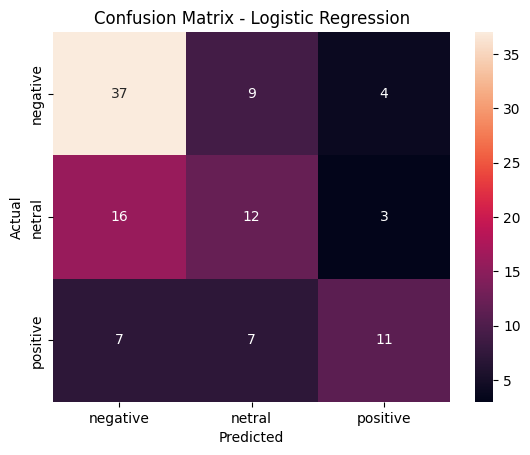


===== Linear SVM =====
Accuracy: 0.5754716981132075
Precision: 0.5798226621301165
Recall: 0.5754716981132075
F1 Score: 0.5666305804722136

Classification Report:
              precision    recall  f1-score   support

    negative       0.61      0.74      0.67        50
      netral       0.47      0.45      0.46        31
    positive       0.67      0.40      0.50        25

    accuracy                           0.58       106
   macro avg       0.58      0.53      0.54       106
weighted avg       0.58      0.58      0.57       106



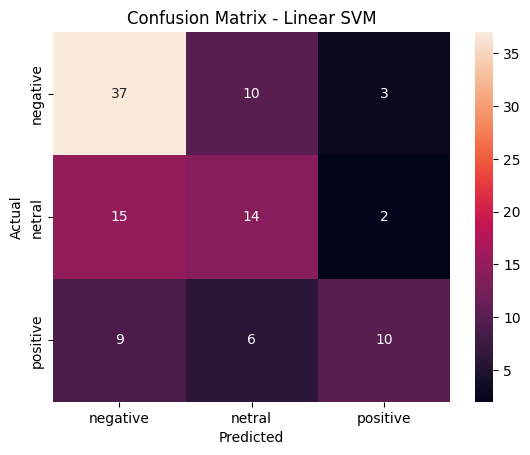


===== Naive Bayes =====
Accuracy: 0.5283018867924528
Precision: 0.5504858845226274
Recall: 0.5283018867924528
F1 Score: 0.42028216279149405

Classification Report:
              precision    recall  f1-score   support

    negative       0.53      1.00      0.69        50
      netral       0.43      0.10      0.16        31
    positive       0.75      0.12      0.21        25

    accuracy                           0.53       106
   macro avg       0.57      0.41      0.35       106
weighted avg       0.55      0.53      0.42       106



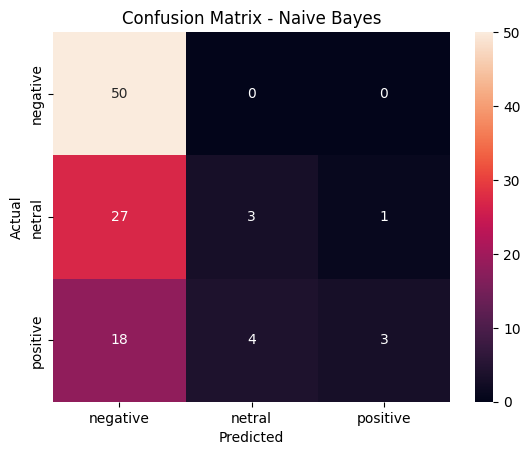

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })
    
    print(f"\n===== {name} =====")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # ==============================
    # CONFUSION MATRIX
    # ==============================
    cm = confusion_matrix(y_test, y_pred)
    labels = sorted(y_test.unique())
    
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# 6. Analyse Results

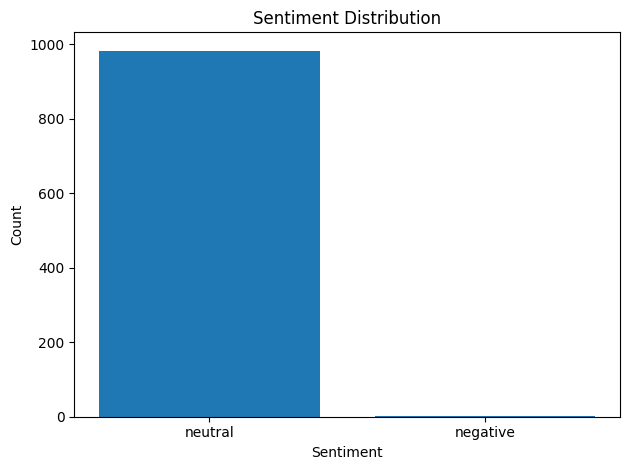

In [ ]:
import matplotlib.pyplot as plt

counts = df["label_bert"].value_counts()

plt.figure()
plt.bar(counts.index, counts.values)
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Distribution")
plt.tight_layout()
plt.show()

# Citations

@misc {wilson_wongso_2023,
    author       = { {Wilson Wongso} },
    title        = { indonesian-roberta-base-sentiment-classifier (Revision e402e46) },
    year         = 2023,
    url          = { https://huggingface.co/w11wo/indonesian-roberta-base-sentiment-classifier },
    doi          = { 10.57967/hf/0644 },
    publisher    = { Hugging Face }
}